---
## ✅ Cell 0 — Imports & Constants
Run this cell first. Every other cell depends on it.

In [ ]:
import os, shutil, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing  import image as keras_image
from tensorflow.keras.models         import Sequential, Model
from tensorflow.keras.layers         import (Conv2D, MaxPooling2D, Flatten,
                                              Dense, Dropout, BatchNormalization,
                                              GlobalAveragePooling2D)
from tensorflow.keras.callbacks      import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers     import Adam
from tensorflow.keras.applications   import MobileNetV2
from sklearn.metrics                 import (confusion_matrix,
                                              classification_report,
                                              accuracy_score)

# ── Paths  (notebook lives in  Deep_Learning/) ────────────────────
RAW_DIR  = Path('dataset2/Garbage classification/Garbage classification')
BASE_DIR = Path('dataset2/dataset')   # split output
TRAIN_DIR = str(BASE_DIR / 'train')
VAL_DIR   = str(BASE_DIR / 'validation')

CLASS_MAP = {
    'cardboard' : 'recyclable',
    'glass'     : 'recyclable',
    'metal'     : 'recyclable',
    'paper'     : 'recyclable',
    'plastic'   : 'recyclable',
    'trash'     : 'non_recyclable',
}
CLASSES     = ['recyclable', 'non_recyclable', 'organic']
NUM_CLASSES = len(CLASSES)


IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
SEED        = 42
TRAIN_RATIO = 0.80


callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                     patience=4, min_lr=1e-7, verbose=1)
]

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'RAW_DIR    : {RAW_DIR.resolve()}')
print(f'RAW exists : {RAW_DIR.exists()}')
print(f'Classes    : {CLASSES}')

TensorFlow : 2.20.0
RAW_DIR    : C:\Users\hp\Desktop\numpy\Deep_Learning\dataset2\Garbage classification\Garbage classification
RAW exists : True
Classes    : ['recyclable', 'non_recyclable', 'organic']


---
## Task 1 — Dataset Collection & Folder Structure

In [2]:
assert RAW_DIR.exists(), f'RAW_DIR not found: {RAW_DIR.resolve()}'

if BASE_DIR.exists():
    shutil.rmtree(BASE_DIR)
    print('Removed old dataset/ split.')

for split in ('train', 'validation'):
    for cls in CLASSES:
        (BASE_DIR / split / cls).mkdir(parents=True, exist_ok=True)

counts = {s: {c: 0 for c in CLASSES} for s in ('train', 'validation')}

for kaggle_cls, our_cls in CLASS_MAP.items():
    src = RAW_DIR / kaggle_cls
    imgs = sorted(src.glob('*.jpg')) + sorted(src.glob('*.png'))
    random.shuffle(imgs)
    cut = int(len(imgs) * TRAIN_RATIO)
    for split, subset in [('train', imgs[:cut]), ('validation', imgs[cut:])]:
        for img in subset:
            dst = BASE_DIR / split / our_cls / f'{kaggle_cls}_{img.name}'
            shutil.copy2(img, dst)
            counts[split][our_cls] += 1

print(f"\n{'Class':<16}{'Train':>8}{'Validation':>12}{'Total':>8}")
for c in CLASSES:
    tr, vl = counts['train'][c], counts['validation'][c]
    print(f'{c:<16}{tr:>8}{vl:>12}{tr+vl:>8}')

tot_tr  = sum(counts['train'].values())
tot_val = sum(counts['validation'].values())
print(f"{'TOTAL':<16}{tot_tr:>8}{tot_val:>12}{tot_tr+tot_val:>8}")

print('\nFolder structure:')
for split in ('train', 'validation'):
    for cls in CLASSES:
        n = counts[split][cls]
        print(f'   dataset/{split}/{cls}/   ({n} images)')

assert tot_tr > 0,  'Training set empty!'
assert tot_val > 0, 'Validation set empty!'
print('\nDataset ready.')

Removed old dataset/ split.

Class              Train  Validation   Total
recyclable          1910         480    2390
non_recyclable       109          28     137
organic                0           0       0
TOTAL               2019         508    2527

Folder structure:
   dataset/train/recyclable/   (1910 images)
   dataset/train/non_recyclable/   (109 images)
   dataset/train/organic/   (0 images)
   dataset/validation/recyclable/   (480 images)
   dataset/validation/non_recyclable/   (28 images)
   dataset/validation/organic/   (0 images)

Dataset ready.


---
## Task 2 — Data Preprocessing

In [4]:


train_datagen = ImageDataGenerator(
    rescale            = 1./255,      
    rotation_range     = 30,         
    horizontal_flip    = True,        
    zoom_range         = 0.20,        
    brightness_range   = [0.7, 1.3],  
    width_shift_range  = 0.10,       
    height_shift_range = 0.10,        
    shear_range        = 0.10,        
    fill_mode          = 'nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

CLASS_NAMES      = list(train_gen.class_indices.keys())
steps_per_epoch  = max(1, train_gen.samples // BATCH_SIZE)
validation_steps = max(1, val_gen.samples   // BATCH_SIZE)

assert train_gen.samples > 0, 'train_gen is empty — re-run Task 1'
assert val_gen.samples   > 0, 'val_gen is empty   — re-run Task 1'

print('Preprocessing pipeline ready')
print(f'   Train images      : {train_gen.samples}')
print(f'   Validation images : {val_gen.samples}')
print(f'   steps_per_epoch   : {steps_per_epoch}')
print(f'   validation_steps  : {validation_steps}')
print(f'   Class indices     : {train_gen.class_indices}')

Found 2019 images belonging to 3 classes.
Found 508 images belonging to 3 classes.
Preprocessing pipeline ready
   Train images      : 2019
   Validation images : 508
   steps_per_epoch   : 63
   validation_steps  : 15
   Class indices     : {'non_recyclable': 0, 'organic': 1, 'recyclable': 2}


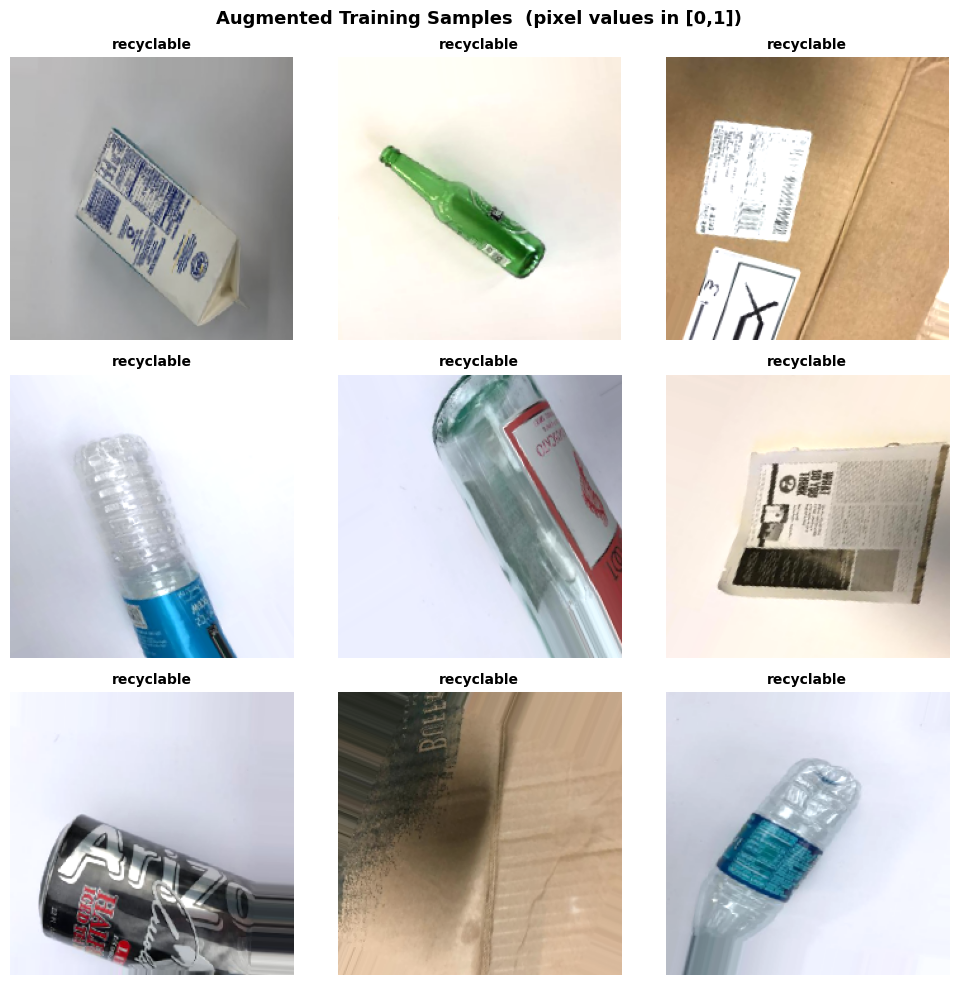

Saved: augmented_samples.png


In [5]:
batch_imgs, batch_labels = next(train_gen)
label_idx = np.argmax(batch_labels, axis=1)
n_show    = min(9, len(batch_imgs))

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Augmented Training Samples  (pixel values in [0,1])',
             fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i < n_show:
        ax.imshow(np.clip(batch_imgs[i], 0, 1))
        ax.set_title(CLASS_NAMES[label_idx[i]], fontsize=10, fontweight='bold')
    else:
        ax.set_visible(False)
    ax.axis('off')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: augmented_samples.png')

---
## Task 3 — CNN Model Development

In [6]:
def build_cnn(input_shape=(224, 224, 3), num_classes=3):
    m = Sequential(name='CustomCNN')
    
    m.add(Conv2D(32, (3,3), activation='relu', padding='same',
                 input_shape=input_shape, name='conv1_1'))
    m.add(BatchNormalization())
    m.add(Conv2D(32, (3,3), activation='relu', padding='same', name='conv1_2'))
    m.add(MaxPooling2D((2,2), name='pool1'))
    m.add(Dropout(0.25))
    
    m.add(Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_1'))
    m.add(BatchNormalization())
    m.add(Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_2'))
    m.add(MaxPooling2D((2,2), name='pool2'))
    m.add(Dropout(0.25))
    
    m.add(Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_1'))
    m.add(BatchNormalization())
    m.add(Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_2'))
    m.add(MaxPooling2D((2,2), name='pool3'))
    m.add(Dropout(0.30))
    
    m.add(Conv2D(256, (3,3), activation='relu', padding='same', name='conv4_1'))
    m.add(BatchNormalization())
    m.add(MaxPooling2D((2,2), name='pool4'))
    m.add(Dropout(0.30))
    
    m.add(Flatten(name='flatten'))
    m.add(Dense(512, activation='relu', name='dense1'))
    m.add(BatchNormalization())
    m.add(Dropout(0.50))
    m.add(Dense(256, activation='relu', name='dense2'))
    m.add(Dropout(0.40))
    m.add(Dense(num_classes, activation='softmax', name='output'))
    return m

cnn_model = build_cnn(num_classes=NUM_CLASSES)
cnn_model.compile(optimizer=Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
cnn_model.summary()

c:\Users\hp\Desktop\numpy\myvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,408,867 (100.74 MB)

 Trainable params: 26,406,883 (100.73 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
print(f'Training for up to 3 epochs  '
      f'(steps_per_epoch={steps_per_epoch}, '
      f'validation_steps={validation_steps})')

cnn_history = cnn_model.fit(
    train_gen,
    steps_per_epoch  = steps_per_epoch,
    validation_data  = val_gen,
    validation_steps = validation_steps,
    epochs           = 3,
    callbacks        = callbacks
)
cnn_model.save('cnn_waste_classifier.keras')
print('\nSaved: cnn_waste_classifier.keras')

Training for up to 3 epochs  (steps_per_epoch=63, validation_steps=15)
Epoch 1/3
23/63 ━━━━━━━━━━━━━━━━━━━━ 5:06 8s/step - accuracy: 0.9405 - loss: 0.2615

In [ ]:
# ── Training curves ───────────────────────────────────────────────
def plot_history(history, title='Custom CNN'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{title} — Training History', fontsize=14, fontweight='bold')
    for ax, m, lbl in [(ax1,'accuracy','Accuracy'),(ax2,'loss','Loss')]:
        ax.plot(history.history[m],
                label='Train', color='steelblue', lw=2)
        ax.plot(history.history[f'val_{m}'],
                label='Validation', color='darkorange', lw=2, ls='--')
        ax.set_xlabel('Epoch'); ax.set_ylabel(lbl); ax.set_title(lbl)
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = title.lower().replace(' ','_') + '_history.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {fname}')

plot_history(cnn_history, 'Custom CNN')
print(f"Best Train Accuracy : {max(cnn_history.history['accuracy'])*100:.2f}%")
print(f"Best Val Accuracy   : {max(cnn_history.history['val_accuracy'])*100:.2f}%")

---
## Task 4 — Model Evaluation (6 Marks)

In [ ]:
# ─────────────────────────────────────────────────────────────────
# TASK 4 — Confusion matrix + accuracy + 5 sample predictions
# ─────────────────────────────────────────────────────────────────

val_gen.reset()
y_probs = cnn_model.predict(val_gen, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)
y_true  = val_gen.classes

acc = accuracy_score(y_true, y_pred)
print(f'\n🎯 Overall Accuracy : {acc*100:.2f}%\n')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Confusion Matrix — Custom CNN',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Actual Label',    fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_cnn.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: confusion_matrix_cnn.png')

In [ ]:
# ── 5 sample predictions ──────────────────────────────────────────
all_val = (list(Path(VAL_DIR).rglob('*.jpg')) +
           list(Path(VAL_DIR).rglob('*.png')))
assert len(all_val) > 0, '❌ No validation images found.'

# Only pick from classes that actually have images
non_empty = [p for p in all_val
             if len(list(p.parent.glob('*.*'))) > 0]
selected = random.sample(non_empty, min(5, len(non_empty)))

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Sample Predictions — Custom CNN\n'
             'Green = Correct  |  Red = Wrong',
             fontsize=12, fontweight='bold')
for ax, img_path in zip(axes, selected):
    img   = keras_image.load_img(img_path, target_size=IMG_SIZE)
    arr   = keras_image.img_to_array(img) / 255.0
    probs = cnn_model.predict(np.expand_dims(arr, 0), verbose=0)[0]
    pred  = CLASS_NAMES[np.argmax(probs)]
    conf  = probs.max() * 100
    true  = img_path.parent.name
    ax.imshow(img)
    ax.set_title(f'Pred: {pred}\n({conf:.1f}%)',
                 color='green' if pred == true else 'red',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel(f'True: {true}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_predictions_cnn.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: sample_predictions_cnn.png')

---
## Task 5 — Transfer Learning with MobileNetV2 (6 Marks)

In [ ]:
# ─────────────────────────────────────────────────────────────────
# TASK 5 — Transfer Learning : MobileNetV2
# ─────────────────────────────────────────────────────────────────

# Step 1 — Pretrained base, no top
base = MobileNetV2(weights='imagenet', include_top=False,
                   input_shape=(*IMG_SIZE, 3))

# Step 2 — Freeze all base layers
base.trainable = False
print(f'MobileNetV2 layers : {len(base.layers)}')
print(f'Frozen             : {sum(1 for l in base.layers if not l.trainable)}')

# Step 3 — Custom head for 3 classes
x   = GlobalAveragePooling2D(name='gap')(base.output)
x   = Dense(256, activation='relu', name='fc1')(x)
x   = BatchNormalization()(x)
x   = Dropout(0.40)(x)
x   = Dense(128, activation='relu', name='fc2')(x)
x   = Dropout(0.30)(x)
out = Dense(NUM_CLASSES, activation='softmax', name='output')(x)

tl_model = Model(inputs=base.input, outputs=out, name='MobileNetV2_TL')
tl_model.compile(optimizer=Adam(1e-3),
                 loss='categorical_crossentropy', metrics=['accuracy'])

trainable = sum(tf.keras.backend.count_params(w)
                for w in tl_model.trainable_weights)
print(f'Trainable params   : {trainable:,}')

In [ ]:
# ── Phase 1 : train head only (base frozen) ───────────────────────
print('🔒 Phase 1 — Training custom head (base frozen)')

tl_train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED
)
tl_val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

tl_hist1 = tl_model.fit(
    tl_train_gen,
    steps_per_epoch  = max(1, tl_train_gen.samples // BATCH_SIZE),
    validation_data  = tl_val_gen,
    validation_steps = max(1, tl_val_gen.samples   // BATCH_SIZE),
    epochs=10, callbacks=callbacks
)
print(f"Phase 1 best val acc : {max(tl_hist1.history['val_accuracy'])*100:.2f}%")

In [ ]:
# ── Phase 2 : unfreeze top 30 layers, fine-tune (low LR) ──────────
print('🔓 Phase 2 — Fine-tuning top 30 layers of MobileNetV2')

base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

tl_model.compile(optimizer=Adam(1e-5),
                 loss='categorical_crossentropy', metrics=['accuracy'])

tl_train_gen.reset()
tl_val_gen.reset()

tl_hist2 = tl_model.fit(
    tl_train_gen,
    steps_per_epoch  = max(1, tl_train_gen.samples // BATCH_SIZE),
    validation_data  = tl_val_gen,
    validation_steps = max(1, tl_val_gen.samples   // BATCH_SIZE),
    epochs=15, callbacks=callbacks
)
tl_model.save('tl_waste_classifier.keras')
print(f"Phase 2 best val acc : {max(tl_hist2.history['val_accuracy'])*100:.2f}%")
print('✅ Saved: tl_waste_classifier.keras')

In [ ]:
# ── Accuracy Comparison ───────────────────────────────────────────
val_gen.reset()
_, cnn_acc = cnn_model.evaluate(val_gen, verbose=0)

tl_val_gen.reset()
_, tl_acc  = tl_model.evaluate(tl_val_gen, verbose=0)

print('\n' + '═'*50)
print(f"  {'Model':<32}{'Val Accuracy':>10}")
print('═'*50)
print(f"  {'Custom CNN':<32}{cnn_acc*100:>9.2f}%")
print(f"  {'MobileNetV2 (Transfer Learning)':<32}{tl_acc*100:>9.2f}%")
print('═'*50)
print(f"  Improvement : {(tl_acc - cnn_acc)*100:+.2f}%")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Custom CNN', 'MobileNetV2\n(Transfer Learning)'],
              [cnn_acc*100, tl_acc*100],
              color=['steelblue','darkorange'], width=0.45,
              edgecolor='white', linewidth=1.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            f'{b.get_height():.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=12)
ax.set_ylim(0, 108)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('Custom CNN vs Transfer Learning\nAccuracy Comparison',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: accuracy_comparison.png')

---
## 📋 Project 1 Summary

| Task | Description | Deliverable |
|------|-------------|-------------|
| **1** | Mapped 6 Kaggle classes → 3 classes (recyclable / non_recyclable / organic), 80/20 split | Folder tree + count table |
| **2** | Normalisation ÷255 + 7 augmentations | Pipeline code + 3×3 sample grid |
| **3** | 4 conv blocks + 2 dense layers + BatchNorm + Dropout | `model.summary()` + accuracy & loss curves |
| **4** | Confusion matrix (3×3) + accuracy score + 5 sample predictions | `confusion_matrix_cnn.png`, `sample_predictions_cnn.png` |
| **5** | MobileNetV2: freeze → train head → fine-tune top 30 layers | Accuracy comparison bar chart |